<a href="https://colab.research.google.com/github/shriya-0802/OsteoArthritis/blob/main/final_inceptionv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import shutil

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# Define paths
train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
list_of_classes = ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe']

In [ ]:
# Function to apply CLAHE to images
def apply_clahe_to_folder(folder_path):
    """Apply CLAHE to all images in a folder"""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    for class_folder in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_folder)
        if os.path.isdir(class_path):
            for filename in os.listdir(class_path):
                if filename.endswith((".jpg", ".png", ".jpeg")):
                    img_path = os.path.join(class_path, filename)
                    img = cv2.imread(img_path, 0)  # Read as grayscale
                    if img is not None:
                        img_clahe = clahe.apply(img)
                        # Convert back to 3-channel for InceptionV3
                        img_clahe_3channel = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
                        cv2.imwrite(img_path, img_clahe_3channel)


In [ ]:
# Apply CLAHE to ALL datasets (train, test, valid) for consistency
print("Applying CLAHE to all datasets...")
for path in [train_path, test_path, valid_path]:
    apply_clahe_to_folder(path)
print("CLAHE application complete!")



Applying CLAHE to all datasets...
CLAHE application complete!


In [ ]:
# Create dataframes for train, test, and validation sets
def create_dataframe(path):
    filepaths = []
    labels = []
    classlist = os.listdir(path)
    for klass in classlist:
        if klass.isdigit():  # Ensure it's a numeric folder
            intklass = int(klass)
            label = list_of_classes[intklass]
            classpath = os.path.join(path, klass)
            if os.path.isdir(classpath):
                flist = os.listdir(classpath)
                for f in flist:
                    if f.endswith((".jpg", ".png", ".jpeg")):
                        fpath = os.path.join(classpath, f)
                        filepaths.append(fpath)
                        labels.append(label)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})



In [ ]:
# Create dataframes
train_df = create_dataframe(train_path)
test_df = create_dataframe(test_path)
valid_df = create_dataframe(valid_path)

print(f'train_df length: {len(train_df)}')
print(f'test_df length: {len(test_df)}')
print(f'valid_df length: {len(valid_df)}')

# Print class distribution
print("\nClass distribution in training set:")
print(train_df['labels'].value_counts())



train_df length: 5790
test_df length: 1656
valid_df length: 826

Class distribution in training set:
labels
Healthy     2298
Minimal     1516
Doubtful    1046
Moderate     757
Severe       173
Name: count, dtype: int64


In [ ]:
# Function to balance dataset
def balance_dataset(df, samples_per_class=None):
    """Balance dataset by undersampling majority classes"""
    df_balanced = pd.DataFrame()
    groups = df.groupby('labels')

    if samples_per_class is None:
        # Use minimum class count as target
        samples_per_class = min(df['labels'].value_counts())

    for label in df['labels'].unique():
        group = groups.get_group(label)
        if len(group) > samples_per_class:
            sampled_group = group.sample(n=samples_per_class, random_state=42)
        else:
            # Oversample minority classes
            sampled_group = group.sample(n=samples_per_class, replace=True, random_state=42)
        df_balanced = pd.concat([df_balanced, sampled_group])

    return df_balanced


In [ ]:
# Balance the training dataset (use 500 samples per class)
train_df_balanced = balance_dataset(train_df, samples_per_class=500)
print(f"\nBalanced training set size: {len(train_df_balanced)}")
print(train_df_balanced['labels'].value_counts())




Balanced training set size: 2500
labels
Severe      500
Minimal     500
Moderate    500
Healthy     500
Doubtful    500
Name: count, dtype: int64


In [ ]:
# Image size
img_size = (224, 224)
batch_size = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
# No augmentation for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_dataframe(
    train_df_balanced,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

valid_gen = val_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)



Found 2500 validated image filenames belonging to 5 classes.
Found 826 validated image filenames belonging to 5 classes.
Found 1656 validated image filenames belonging to 5 classes.


In [ ]:
# Get class information
classes = list(train_gen.class_indices.keys())
class_count = len(classes)
print(f"\nNumber of classes: {class_count}")
print(f"Classes: {classes}")



Number of classes: 5
Classes: ['Doubtful', 'Healthy', 'Minimal', 'Moderate', 'Severe']


In [ ]:
# Build the model with proper regularization
def build_model():
    # Load InceptionV3 with pre-trained weights
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    # Freeze base model layers initially
    base_model.trainable = False


    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(class_count, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model



In [ ]:
# Build model
model, base_model = build_model()



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,992,677 (87.71 MB)

 Trainable params: 1,185,797 (4.52 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [ ]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)



In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)


In [ ]:
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/Colab Notebooks/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)


In [ ]:
# Stage 1: Train only the top layers
print("\n" + "="*50)
print("Stage 1: Training top layers (frozen base model)")
print("="*50)




Stage 1: Training top layers (frozen base model)


In [ ]:
history_stage1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=valid_gen,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)


Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2735 - loss: 2.2314
Epoch 1: val_accuracy improved from None to 0.26271, saving model to /content/drive/MyDrive/Colab Notebooks/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 365s 5s/step - accuracy: 0.3040 - loss: 2.0522 - val_accuracy: 0.2627 - val_loss: 1.4500 - learning_rate: 0.0010
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3249 - loss: 1.6994
Epoch 2: val_accuracy improved from 0.26271 to 0.41283, saving model to /content/drive/MyDrive/Colab Notebooks/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 342s 4s/step - accuracy: 0.3300 - loss: 1.6154 - val_accuracy: 0.4128 - val_loss: 1.3627 - learning_rate: 0.0010
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3265 - loss: 1.4905
Epoch 3: val_accuracy did not improv

In [ ]:
# Stage 2: Fine-tune the last few layers of the base model
print("\n" + "="*50)
print("Stage 2: Fine-tuning last layers of InceptionV3")
print("="*50)



Stage 2: Fine-tuning last layers of InceptionV3


In [ ]:
# Unfreeze the last 50 layers of the base model
base_model.trainable = True


In [ ]:
# Freeze all layers except the last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False



In [ ]:
# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [33]:
# Continue training
history_stage2 = model.fit(
    train_gen,
    epochs=30,
    validation_data=valid_gen,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)



Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3545 - loss: 1.3935
Epoch 1: val_accuracy did not improve from 0.43584
79/79 ━━━━━━━━━━━━━━━━━━━━ 374s 5s/step - accuracy: 0.3544 - loss: 1.3934 - val_accuracy: 0.3814 - val_loss: 1.3598 - learning_rate: 4.0000e-07
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3884 - loss: 1.3478
Epoch 2: val_accuracy did not improve from 0.43584
79/79 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.3856 - loss: 1.3601 - val_accuracy: 0.3826 - val_loss: 1.3439 - learning_rate: 4.0000e-07
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3725 - loss: 1.3747
Epoch 3: val_accuracy did not improve from 0.43584
79/79 ━━━━━━━━━━━━━━━━━━━━ 382s 5s/step - accuracy: 0.3672 - loss: 1.3721 - val_accuracy: 0.3777 - val_loss: 1.3383 - learning_rate: 4.0000e-07
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3647 - loss: 1.3894
Epoch 4: val_accuracy did not improve from 0.43584
79/79 ━━━━━━━━━━━━━━━━━━━━ 368s 

In [34]:
# Combine histories for plotting
history = {
    'accuracy': history_stage1.history['accuracy'] + history_stage2.history['accuracy'],
    'val_accuracy': history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy'],
    'loss': history_stage1.history['loss'] + history_stage2.history['loss'],
    'val_loss': history_stage1.history['val_loss'] + history_stage2.history['val_loss']
}


In [35]:
# Load best model
model.load_weights('/content/drive/MyDrive/Colab Notebooks/best_model.keras')



/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 72 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
# Function to evaluate model
def evaluate_model(model, test_gen, classes):
    """Evaluate model on test set"""
    print("\n" + "="*50)
    print("Evaluating on Test Set")
    print("="*50)

    # Make predictions
    predictions = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes

    # Calculate accuracy
    accuracy = np.mean(y_pred == y_true) * 100
    print(f"\nTest Accuracy: {accuracy:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    return accuracy, y_pred, y_true



Evaluating on Test Set
52/52 ━━━━━━━━━━━━━━━━━━━━ 819s 16s/step

Test Accuracy: 41.97%


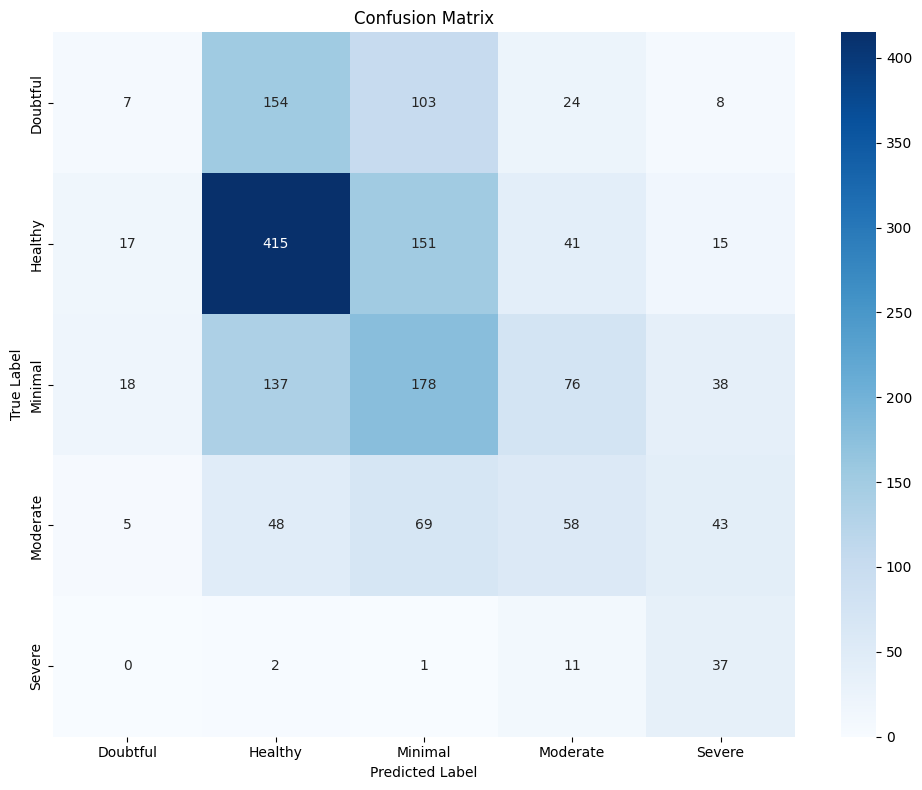


Classification Report:
              precision    recall  f1-score   support

    Doubtful       0.15      0.02      0.04       296
     Healthy       0.55      0.65      0.59       639
     Minimal       0.35      0.40      0.38       447
    Moderate       0.28      0.26      0.27       223
      Severe       0.26      0.73      0.39        51

    accuracy                           0.42      1656
   macro avg       0.32      0.41      0.33      1656
weighted avg       0.38      0.42      0.39      1656



In [37]:
# Evaluate model
accuracy, y_pred, y_true = evaluate_model(model, test_gen, classes)



In [38]:
# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    axes[0].plot(history['accuracy'], label='Training Accuracy')
    axes[0].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Plot loss
    axes[1].plot(history['loss'], label='Training Loss')
    axes[1].plot(history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


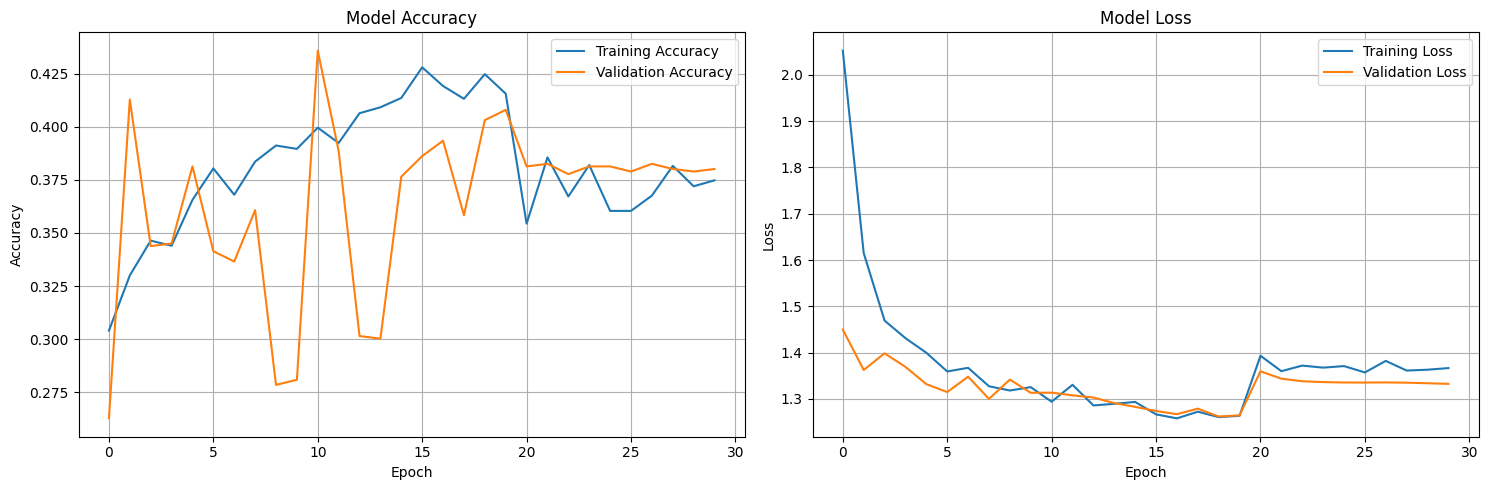

In [39]:
plot_training_history(history)


In [40]:
# Save the final model
model_save_path = '/content/drive/MyDrive/Colab Notebooks/final_inceptionv3_model.keras'
model.save(model_save_path)
print(f"\nModel saved to: {model_save_path}")




Model saved to: /content/drive/MyDrive/Colab Notebooks/final_inceptionv3_model.keras


In [43]:
# Function to predict single image
def predict_image(image_path, model, classes):
    """Predict class for a single image"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)
    pred_class = classes[np.argmax(pred)]
    confidence = np.max(pred) * 100

    return pred_class, confidence
print("\n" + "="*60)
print("Model is ready for predictions!")
print("="*60)




Model is ready for predictions!



Sample Predictions on Validation Set
Image 1: True: Severe       | Predicted: Minimal      | Confidence: 41.13%


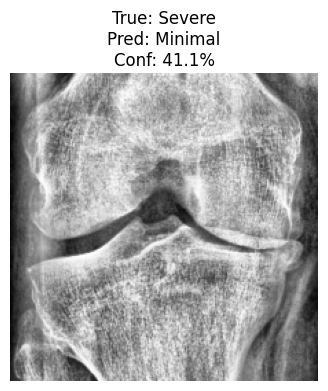

Image 2: True: Doubtful     | Predicted: Minimal      | Confidence: 27.44%


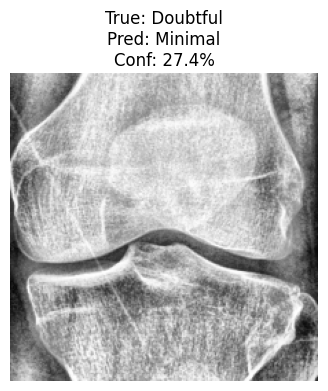

Image 3: True: Doubtful     | Predicted: Minimal      | Confidence: 36.44%


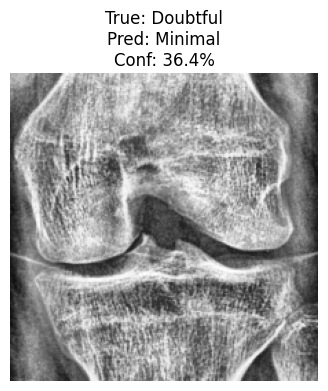

Image 4: True: Doubtful     | Predicted: Healthy      | Confidence: 23.25%


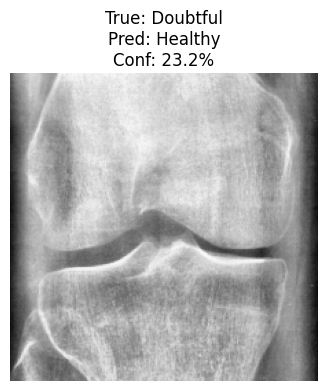

Image 5: True: Doubtful     | Predicted: Healthy      | Confidence: 41.09%


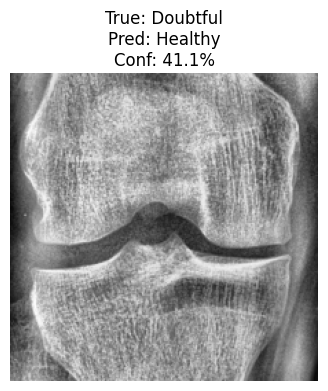

In [46]:
# ============================================
# SAMPLE PREDICTIONS ON VALIDATION SET
# ============================================

print("\n" + "="*60)
print("Sample Predictions on Validation Set")
print("="*60)

# Reset validation generator
valid_gen.reset()

# Get 5 sample predictions
for i in range(5):
    try:
        # Get a batch of images and labels
        images, labels = next(valid_gen)

        # Take the first image from the batch
        img = images[0:1]  # Keep batch dimension
        true_label = labels[0]

        # Make prediction
        pred = model.predict(img, verbose=0)
        pred_class = classes[np.argmax(pred[0])]
        true_class = classes[np.argmax(true_label)]
        confidence = np.max(pred[0]) * 100

        print(f"Image {i+1}: True: {true_class:12s} | Predicted: {pred_class:12s} | Confidence: {confidence:.2f}%")

        # Display the image
        plt.figure(figsize=(4, 4))
        plt.imshow(images[0])
        plt.title(f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%")
        plt.axis('off')
        plt.show()

    except StopIteration:
        print("Reached end of validation generator")
        break